# 🔧 Notebook 02: Data Preprocessing & MultimodalDataset

**Objective:** Transform raw MedPix data into model-ready tensors.

**Sections:**
1. Load master DataFrame from Notebook 01
2. Train / Validation / Test split (stratified)
3. Image preprocessing pipeline (CLAHE + augmentation)
4. Text cleaning + tokenization
5. MultimodalDataset + DataLoader verification
6. Save processed splits

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

import config
from src.training.multimodal_predictor import MultimodalDataset

torch.manual_seed(config.RANDOM_SEED)
np.random.seed(config.RANDOM_SEED)

print(f'PyTorch version:      {torch.__version__}')
print(f'CUDA available:       {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device:         {DEVICE}')

PyTorch version:      2.6.0+cu124
CUDA available:       True
Using device:         cuda


## 1️⃣ Load Master DataFrame

In [2]:
df = pd.read_csv('../data/medpix_master.csv')
print(f'Loaded master DataFrame: {len(df)} rows, {df.shape[1]} columns')
print(f'Class distribution:')
print(df['label_name'].value_counts())

# Drop rows with empty text (cannot train without text input)
before = len(df)
df = df[df['text'].str.len() > 10].reset_index(drop=True)
print(f'\nDropped {before - len(df)} rows with insufficient text')
print(f'Final dataset size: {len(df)}')

Loaded master DataFrame: 2050 rows, 21 columns
Class distribution:
label_name
Neoplasm                  550
Clinical Sign/Other       455
Congenital                252
Vascular                  230
Idiopathic/Unknown        168
Trauma                    133
Infection                  92
Obstruction/Mechanical     69
Inflammatory               60
Degenerative/Metabolic     41
Name: count, dtype: int64

Dropped 1 rows with insufficient text
Final dataset size: 2049


## 2️⃣ Stratified Train / Val / Test Split

In [3]:
# First split: (train+val) vs test
df_trainval, df_test = train_test_split(
    df, test_size=config.TEST_SPLIT,
    stratify=df['label'],
    random_state=config.RANDOM_SEED,
)

# Second split: train vs val (from trainval)
val_fraction = config.VAL_SPLIT / (1 - config.TEST_SPLIT)  # Relative fraction
df_train, df_val = train_test_split(
    df_trainval, test_size=val_fraction,
    stratify=df_trainval['label'],
    random_state=config.RANDOM_SEED,
)

print(f'Train size:      {len(df_train):>6}  ({len(df_train)/len(df)*100:.1f}%)')
print(f'Validation size: {len(df_val):>6}  ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test size:       {len(df_test):>6}  ({len(df_test)/len(df)*100:.1f}%)')

# Verify stratification worked
print('\nClass distribution in each split:')
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    dist = split['label'].value_counts().sort_index()
    print(f'  {name}: {dict(dist)}')

Train size:        1433  (69.9%)
Validation size:    308  (15.0%)
Test size:          308  (15.0%)

Class distribution in each split:
  Train: {0: np.int64(384), 1: np.int64(93), 2: np.int64(160), 3: np.int64(176), 4: np.int64(64), 5: np.int64(42), 6: np.int64(29), 7: np.int64(49), 8: np.int64(118), 9: np.int64(318)}
  Val: {0: np.int64(82), 1: np.int64(20), 2: np.int64(35), 3: np.int64(38), 4: np.int64(14), 5: np.int64(9), 6: np.int64(6), 7: np.int64(10), 8: np.int64(25), 9: np.int64(69)}
  Test: {0: np.int64(83), 1: np.int64(20), 2: np.int64(35), 3: np.int64(38), 4: np.int64(14), 5: np.int64(9), 6: np.int64(6), 7: np.int64(10), 8: np.int64(25), 9: np.int64(68)}


## 3️⃣ Image Preprocessing Pipeline

In [4]:
# ── TRAIN transforms: augmentation for generalization ──────────────────────
# Medical image augmentation principles:
#   - Horizontal flip: anatomy is (partially) symmetric
#   - Random rotation ±15°: scanner positioning variation
#   - Color jitter (brightness/contrast only): CLAHE-equivalent augmentation
#   - NO vertical flip, shear, or perspective: clinically invalid
#   - Normalize with ImageNet stats (standard for transfer learning)

train_transform = T.Compose([
    T.Resize((config.IMAGE_SIZE[0] + 24, config.IMAGE_SIZE[1] + 24)),  # Slight oversize for cropping
    T.RandomCrop(config.IMAGE_SIZE),                  # Random crop to add positional variation
    T.RandomHorizontalFlip(p=0.5),                   # 50% horizontal flip
    T.RandomRotation(degrees=15),                     # Small rotation ±15°
    T.ColorJitter(brightness=0.2, contrast=0.2),      # Brightness/contrast jitter
    T.ToTensor(),
    T.Normalize(mean=config.IMG_MEAN, std=config.IMG_STD),
])

# ── VAL/TEST transforms: NO augmentation, deterministic ───────────────────
val_test_transform = T.Compose([
    T.Resize(config.IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize(mean=config.IMG_MEAN, std=config.IMG_STD),
])

print('Train transform pipeline:')
print(train_transform)
print('\nVal/Test transform pipeline:')
print(val_test_transform)

Train transform pipeline:
Compose(
    Resize(size=(248, 248), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)

Val/Test transform pipeline:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


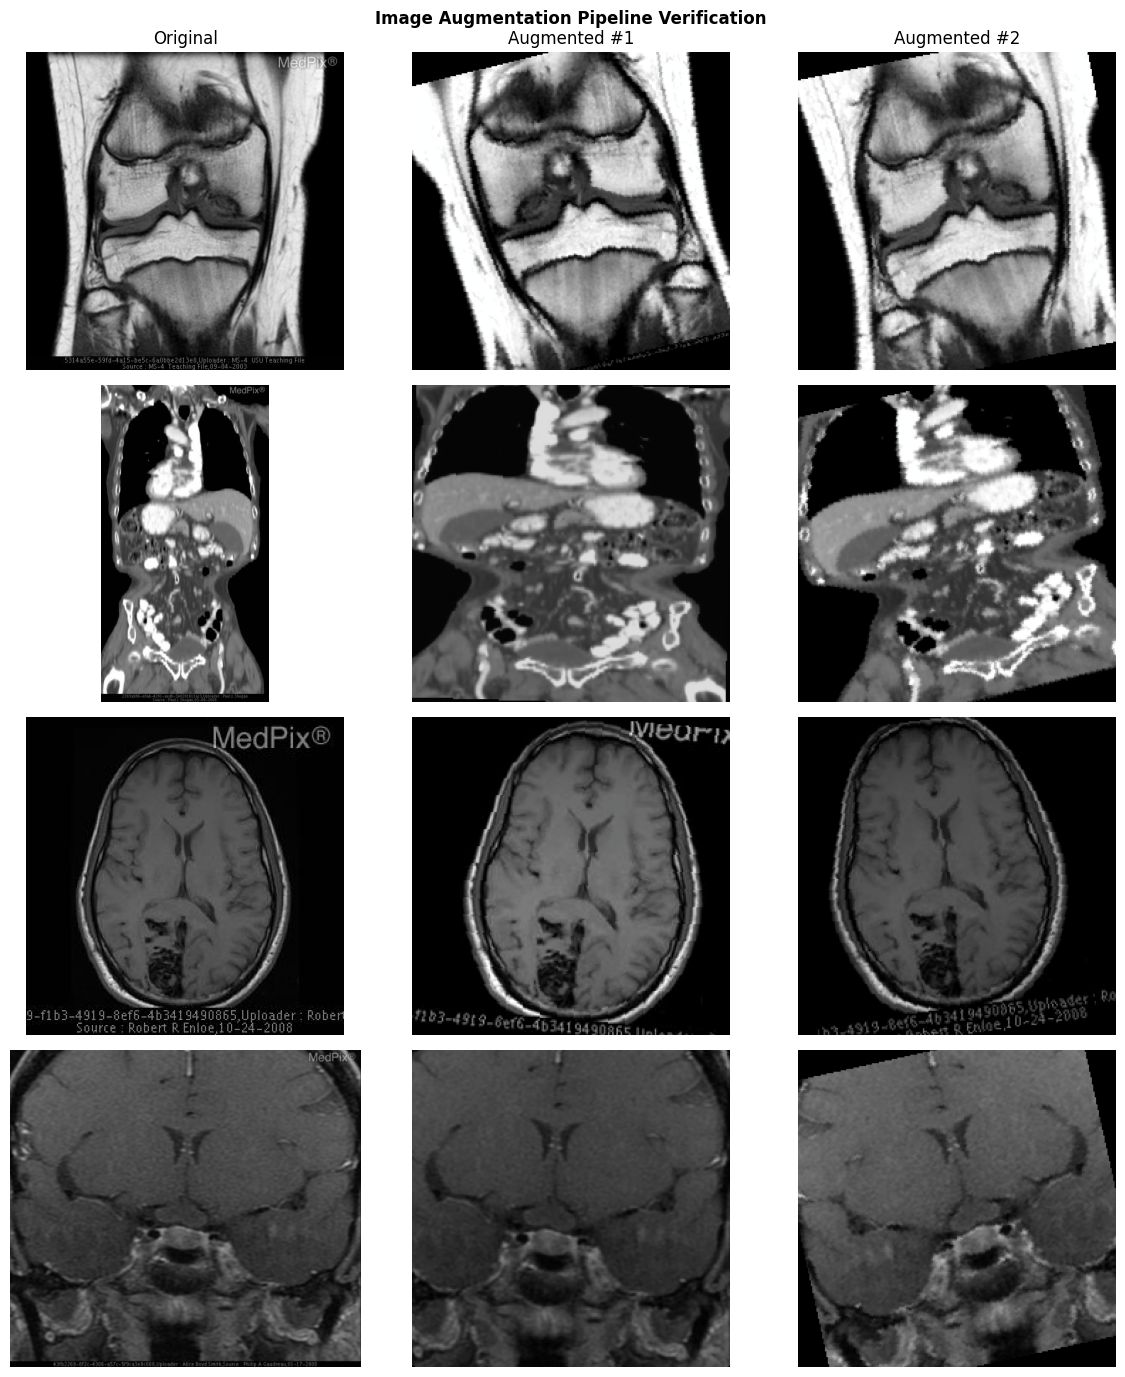

In [5]:
# ── Visualize augmentations on 4 sample images ────────────────────────────
sample_paths = df_train.sample(4, random_state=1)['image_path'].tolist()

fig, axes = plt.subplots(4, 3, figsize=(12, 14))
denorm_mean = np.array(config.IMG_MEAN)
denorm_std  = np.array(config.IMG_STD)

def tensor_to_displayable(t):
    """Convert normalized tensor back to displayable numpy image."""
    arr = t.permute(1, 2, 0).numpy()
    arr = arr * denorm_std + denorm_mean  # Denormalize
    return np.clip(arr, 0, 1)

for i, img_path in enumerate(sample_paths):
    img = Image.open(img_path).convert('RGB')
    axes[i, 0].imshow(img); axes[i, 0].set_title('Original' if i==0 else ''); axes[i, 0].axis('off')
    
    t1 = train_transform(img)
    axes[i, 1].imshow(tensor_to_displayable(t1)); axes[i, 1].set_title('Augmented #1' if i==0 else ''); axes[i, 1].axis('off')
    
    t2 = train_transform(img)
    axes[i, 2].imshow(tensor_to_displayable(t2)); axes[i, 2].set_title('Augmented #2' if i==0 else ''); axes[i, 2].axis('off')

plt.suptitle('Image Augmentation Pipeline Verification', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/augmentation_demo.png', bbox_inches='tight', dpi=150)
plt.show()

## 4️⃣ Text Tokenizer Validation

In [6]:
print(f'Loading tokenizer: {config.TEXT_ENCODER_MODEL}')
hf_token = config.HF_TOKEN if config.HF_TOKEN != 'YOUR_HF_TOKEN_HERE' else None
tokenizer = AutoTokenizer.from_pretrained(config.TEXT_ENCODER_MODEL, token=hf_token)
print(f'Tokenizer vocab size: {tokenizer.vocab_size:,}')

# Test tokenization on sample clinical text
sample_text = df['text'].iloc[0]
print(f'\nSample text (first 200 chars):\n{sample_text[:200]}')

enc = tokenizer(
    sample_text,
    max_length=config.MAX_TEXT_LENGTH,
    padding='max_length',
    truncation=True,
    return_tensors='pt',
)
print(f'\nTokenized output shapes:')
print(f'  input_ids:      {enc["input_ids"].shape}')
print(f'  attention_mask: {enc["attention_mask"].shape}')

# Show how many tokens are actually used (non-pad)
n_real_tokens = enc['attention_mask'].sum().item()
print(f'  Real tokens:    {n_real_tokens}/{config.MAX_TEXT_LENGTH}')

Loading tokenizer: emilyalsentzer/Bio_ClinicalBERT
Tokenizer vocab size: 28,996

Sample text (first 200 chars):
73-year-old male with hematuria and numerous white blood cells found on UA Bladder with thickened wall and diverticulum on the right.  Diverticulum is mostly likely secondary to chronic outflow obstru

Tokenized output shapes:
  input_ids:      torch.Size([1, 256])
  attention_mask: torch.Size([1, 256])
  Real tokens:    78/256


## 5️⃣ MultimodalDataset + DataLoader Verification

In [7]:
# Create all three datasets
train_dataset = MultimodalDataset(
    df=df_train,
    image_transform=train_transform,
    tokenizer=tokenizer,
    max_length=config.MAX_TEXT_LENGTH,
)
val_dataset = MultimodalDataset(
    df=df_val,
    image_transform=val_test_transform,
    tokenizer=tokenizer,
    max_length=config.MAX_TEXT_LENGTH,
)
test_dataset = MultimodalDataset(
    df=df_test,
    image_transform=val_test_transform,
    tokenizer=tokenizer,
    max_length=config.MAX_TEXT_LENGTH,
)

print(f'Train dataset: {len(train_dataset)} samples')
print(f'Val dataset:   {len(val_dataset)} samples')
print(f'Test dataset:  {len(test_dataset)} samples')

# Test a single sample
sample = train_dataset[0]
print('\nSample tensor shapes:')
for k, v in sample.items():
    if hasattr(v, 'shape'):
        print(f'  {k}: {v.shape} (dtype={v.dtype})')
    else:
        print(f'  {k}: {v}')

Train dataset: 1433 samples
Val dataset:   308 samples
Test dataset:  308 samples

Sample tensor shapes:
  image: torch.Size([3, 224, 224]) (dtype=torch.float32)
  input_ids: torch.Size([256]) (dtype=torch.int64)
  attention_mask: torch.Size([256]) (dtype=torch.int64)
  image_id: MPX1394_synpic22908
  label: torch.Size([]) (dtype=torch.int64)


In [8]:
# Create DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE,
    shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available()
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available()
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=config.BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available()
)

# Verify first batch
batch = next(iter(train_loader))
print('First batch shapes:')
for k, v in batch.items():
    if hasattr(v, 'shape'):
        print(f'  {k}: {v.shape}')
    else:
        print(f'  {k}: {type(v)}')

print(f'\nLabels in first batch: {batch["label"].tolist()}')
print(f'Class names: {[config.CLASS_NAMES[l] for l in batch["label"].tolist()]}')
print('\n✅ DataLoaders verified. Ready for training.')

First batch shapes:
  image: torch.Size([8, 3, 224, 224])
  input_ids: torch.Size([8, 256])
  attention_mask: torch.Size([8, 256])
  image_id: <class 'list'>
  label: torch.Size([8])

Labels in first batch: [3, 5, 3, 2, 3, 0, 9, 0]
Class names: ['Congenital', 'Inflammatory', 'Congenital', 'Vascular', 'Congenital', 'Neoplasm', 'Clinical Sign/Other', 'Neoplasm']

✅ DataLoaders verified. Ready for training.


## 6️⃣ Save Processed Splits

In [9]:
import os
os.makedirs('../data/processed', exist_ok=True)

df_train.to_csv('../data/processed/train.csv', index=False)
df_val.to_csv('../data/processed/val.csv', index=False)
df_test.to_csv('../data/processed/test.csv', index=False)

print('Splits saved:')
print(f'  data/processed/train.csv — {len(df_train)} rows')
print(f'  data/processed/val.csv   — {len(df_val)} rows')
print(f'  data/processed/test.csv  — {len(df_test)} rows')
print('\n✅ Preprocessing complete. Proceed to Notebook 03: Model Training.')

Splits saved:
  data/processed/train.csv — 1433 rows
  data/processed/val.csv   — 308 rows
  data/processed/test.csv  — 308 rows

✅ Preprocessing complete. Proceed to Notebook 03: Model Training.
